## 사용자 데이터 샘플링 시각화

## 이름 및 닉네임 보기

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from datetime import datetime
from collections import Counter

from namae import generate_names
from ninckname import generate_usernames
from amoosoo import generateMoney, generateLastVisitDate, generateRank, generateStartDate

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

N = 100_000
names = generate_names(N, include_compound_surname=True)
usernames = generate_usernames(numUsernames=N)
moneys = generateMoney(N)
ranks = generateRank(N)
start_dates = [datetime.strptime(d, "%Y-%m-%d") for d in generateStartDate(N)]
last_visits_raw = generateLastVisitDate(N)
last_visits = [datetime.strptime(d, "%Y-%m-%d %H:%M:%S") if d else None for d in last_visits_raw]

print(f"생성 완료: {N:,}건")
print(f"  name 샘플: {names[:5]}")
print(f"  nickname 샘플: {list(usernames[:5])}")


생성 완료: 100,000건
  name 샘플: ['정채은', '배현희', '서현연', '허태진', '강희지']
  nickname 샘플: [np.str_('retro_c_huylw8f'), np.str_('calm_st_0jffsph'), np.str_('blue_do_4fsp78p'), np.str_('fuzzy_s_2kkmhg7'), np.str_('tiny_fi_js2hnnt')]


In [2]:
from collections import Counter

name_len_dist = Counter(len(n) for n in names)
total = len(names)
print("=== 이름 글자수 분포 ===")
for length in sorted(name_len_dist):
    cnt = name_len_dist[length]
    print(f"  {length}글자: {cnt:>7,}건  ({cnt/total*100:.1f}%)  예) {[n for n in names if len(n)==length][:3]}")


=== 이름 글자수 분포 ===
  2글자:   2,677건  (2.7%)  예) ['권민', '방연', '공수']
  3글자:  85,715건  (85.7%)  예) ['정채은', '배현희', '서현연']
  4글자:  11,608건  (11.6%)  예) ['서문채현', '서문미서', '서문현진']


## 그래프로 확인

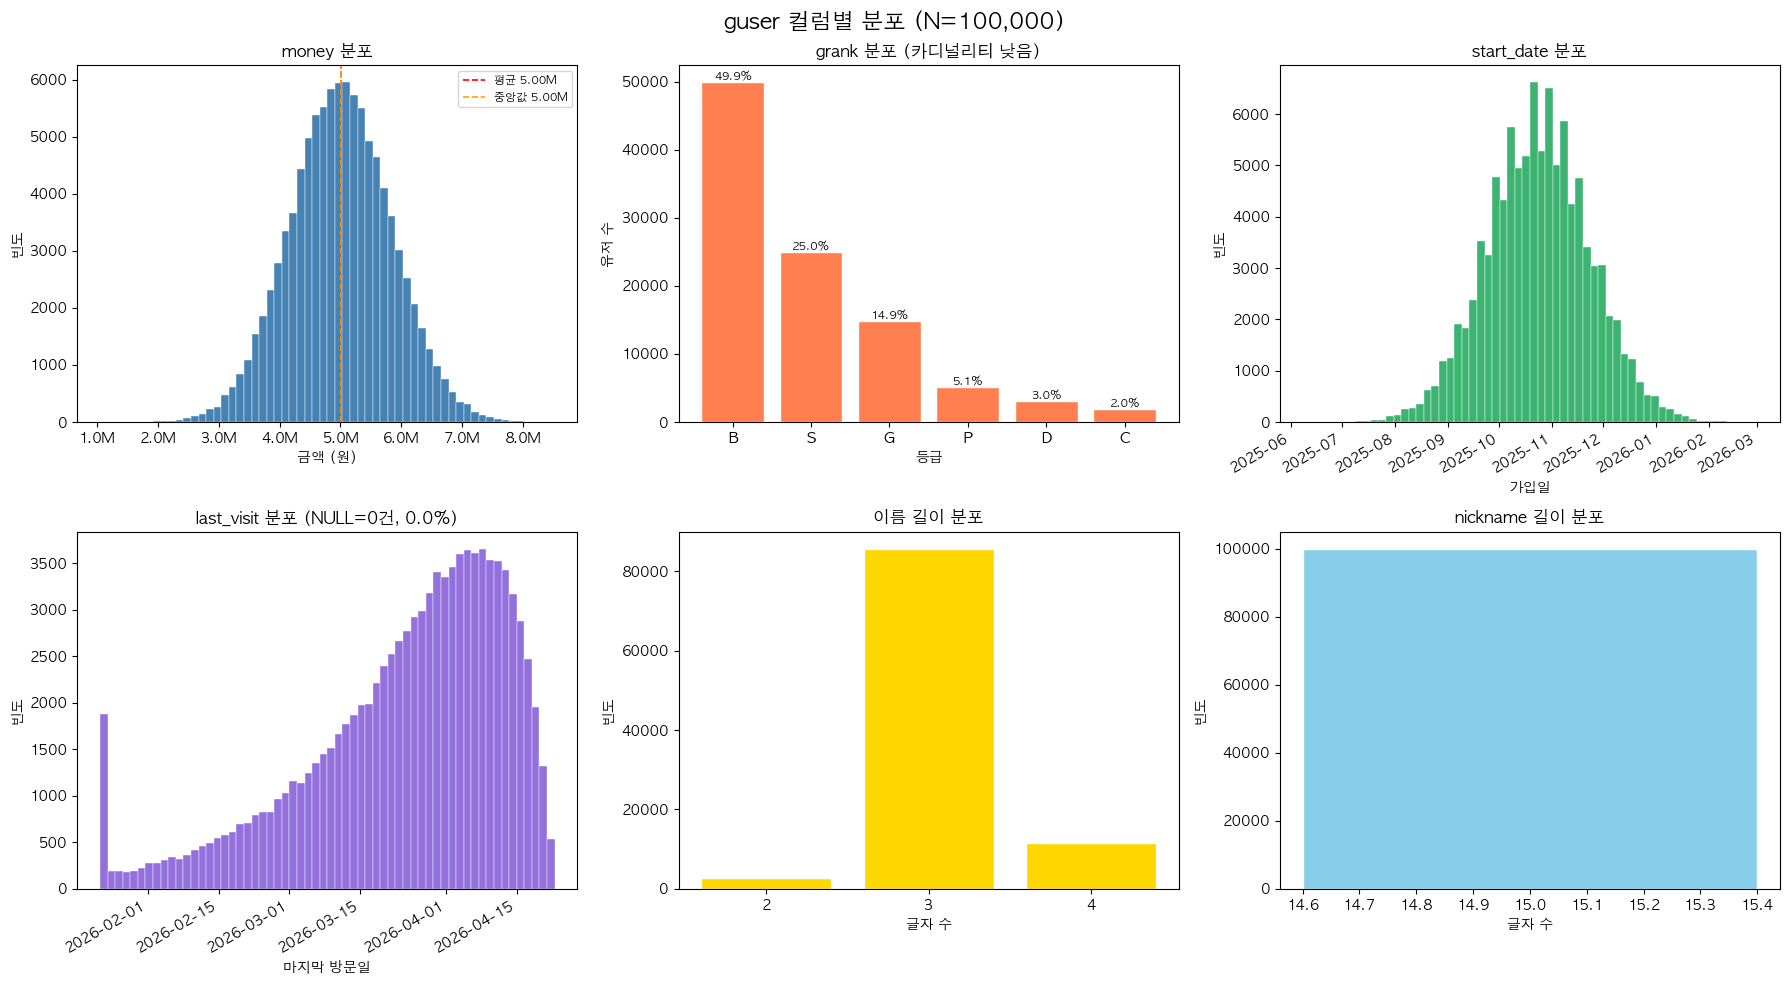

이미지 저장 완료: images/data_distribution.png


In [3]:
import os
os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'guser 컬럼별 분포 (N={N:,})', fontsize=16, fontweight='bold')

# 1. money 분포
ax = axes[0, 0]
ax.hist(moneys, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('money 분포')
ax.set_xlabel('금액 (원)')
ax.set_ylabel('빈도')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
mean_m, median_m = np.mean(moneys), np.median(moneys)
ax.axvline(mean_m, color='red', linestyle='--', linewidth=1.2, label=f'평균 {mean_m/1e6:.2f}M')
ax.axvline(median_m, color='orange', linestyle='--', linewidth=1.2, label=f'중앙값 {median_m/1e6:.2f}M')
ax.legend(fontsize=8)

# 2. grank 분포 (카디널리티 확인) - 비율 내림차순 정렬
ax = axes[0, 1]
rank_counts = Counter(ranks)
rank_order = sorted(rank_counts.keys(), key=lambda r: rank_counts[r], reverse=True)
x_pos = range(len(rank_order))
bars = ax.bar(x_pos, [rank_counts[r] for r in rank_order], color='coral', edgecolor='white')
ax.set_title('grank 분포 (카디널리티 낮음)')
ax.set_xlabel('등급')
ax.set_ylabel('유저 수')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(rank_order, fontsize=11)
for bar, r in zip(bars, rank_order):
    pct = rank_counts[r] / N * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontsize=8)

# 3. start_date 분포
ax = axes[0, 2]
ax.hist(start_dates, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.set_title('start_date 분포')
ax.set_xlabel('가입일')
ax.set_ylabel('빈도')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 4. last_visit 분포 (NULL 포함)
ax = axes[1, 0]
valid_visits = [v for v in last_visits if v is not None]
null_cnt = len(last_visits) - len(valid_visits)
ax.hist(valid_visits, bins=60, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.set_title(f'last_visit 분포 (NULL={null_cnt:,}건, {null_cnt/N*100:.1f}%)')
ax.set_xlabel('마지막 방문일')
ax.set_ylabel('빈도')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 5. 이름 길이 분포
ax = axes[1, 1]
name_lens = Counter(len(n) for n in names)
ax.bar(name_lens.keys(), name_lens.values(), color='gold', edgecolor='white')
ax.set_title('이름 길이 분포')
ax.set_xlabel('글자 수')
ax.set_ylabel('빈도')
ax.set_xticks(sorted(name_lens.keys()))

# 6. nickname 길이 분포
ax = axes[1, 2]
nick_lens = Counter(len(n) for n in usernames)
sorted_lens = sorted(nick_lens.keys())
ax.bar(sorted_lens, [nick_lens[l] for l in sorted_lens], color='skyblue', edgecolor='white')
ax.set_title('nickname 길이 분포')
ax.set_xlabel('글자 수')
ax.set_ylabel('빈도')

plt.tight_layout()
plt.savefig('images/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("이미지 저장 완료: images/data_distribution.png")


In [5]:
print("=== 컬럼별 요약 통계 ===\n")

print(f"[money]")
print(f"  min={min(moneys):>12,.0f}  max={max(moneys):>12,.0f}")
print(f"  mean={np.mean(moneys):>11,.0f}  median={np.median(moneys):>9,.0f}  std={np.std(moneys):>11,.0f}")

print(f"\n[grank] 카디널리티 = {len(rank_counts)}")
for r in sorted(rank_counts, key=lambda r: rank_counts[r], reverse=True):
    print(f"  {r}: {rank_counts[r]:>7,} ({rank_counts[r]/N*100:.1f}%)")

print(f"\n[start_date]  min={min(start_dates).date()}  max={max(start_dates).date()}")

print(f"\n[last_visit]  유효={len(valid_visits):,}  NULL={null_cnt:,} ({null_cnt/N*100:.1f}%)")
if valid_visits:
    print(f"  min={min(valid_visits)}  max={max(valid_visits)}")

print(f"\n[name]  고유값={len(set(names)):,} / {N:,}  중복률={1 - len(set(names))/N:.4%}")
print(f"\n[nickname]  고유값={len(set(usernames)):,} / {N:,}  중복률={1 - len(set(usernames))/N:.4%}")


=== 컬럼별 요약 통계 ===

[money]
  min=   1,488,400  max=   8,532,600
  mean=  5,000,282  median=5,001,750  std=    832,130

[grank] 카디널리티 = 6
  B:  50,066 (50.1%)
  S:  24,993 (25.0%)
  G:  14,906 (14.9%)
  P:   5,030 (5.0%)
  D:   3,033 (3.0%)
  C:   1,972 (2.0%)

[start_date]  min=2025-06-12  max=2026-03-01

[last_visit]  유효=100,000  NULL=0 (0.0%)
  min=2026-01-22 12:19:45  max=2026-04-22 10:33:00

[name]  고유값=41,521 / 100,000  중복률=58.4790%

[nickname]  고유값=100,000 / 100,000  중복률=0.0000%
